# Quick Draw Doodle Images Classification

> Multi-Class Image Classification using custom CNN architecture.

- toc:true
- branch: master
- badges: true
- comments: true
- author: Pratik Kumar
- categories: [PyTorch, CNN, PCA, t-SNE]


## Introduction
---
In this notebook we will be implementing a modified version of LeNet-5, a neural network model that consists convolutional layers and was designed for classifying handwritten characters. Instead of classifying the over-used handwritten digits(MNIST) dataset, we will be using the Quick Draw Doodle Datasets. The dataset is present in tensorflow datasets. Hence we will be loading it from there, for which <i><b>tensorflow</b></i> latest version is required. 

CNNs are found everywhere in modern computer vision. The post aims to discuss Image Classification using CNN implemented in <i><b>PyTorch</b></i> Framework. The jupyter-notebook blog post comes with direct code and output all at one place. All thanks to creators of <b>fastpages</b>!

You can also try the [Quick Draw](https://quickdraw.withgoogle.com)!


<img src = "https://github.com/pr2tik1/sketch-recognition/blob/master/assets/img.png">

##  Data 
---
The <i>Quick Draw Dataset</i> is a collection of 50 million drawings across 345 categories, contributed by players of the game Quick, Draw! The bitmap dataset contains these drawings converted from vector format into <b>28x28 grayscale images</b>. The drawings were captured as timestamped vectors, tagged with metadata including what the player was asked to draw and in which country the player was located. This is available in tensorflow_datasets within 'quickdraw_bitmap'. We will be loading only <b>10</b> classes from the 345 categories and aroung <b>50,000</b> images of each class. To change the number of classes or images, change the values from utility file, <i>utils.py</i>, imported from sketch_recog folder.

#### Importing libraries

In [4]:
#collapse-hide

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
%matplotlib inline

import math
import datetime
import platform
import pathlib
import random

import warnings
warnings.filterwarnings("ignore")

import os
import urllib.request
import seaborn as sns
from sklearn.manifold import TSNE
from PIL import Image, ImageDraw, ImageOps
from sketch_recog.utils import download,load 
from sketch_recog.training import get_predictions, train, evaluate, epoch_time,\
                  count_parameters, calculate_accuracy
from sketch_recog.visualize import get_representations,get_tsne, get_pca, plot_representations

#### Downloading Data

Downloading the dataset as .npy files and storing them in 'data' folder. Make sure the 'data' folder directory is not already present. In case already downloaded, comment the 'download()' function call. The dataset is quite big, downloading will however take time based upon user's internet speed. (Click to expand)

In [5]:
#collapse-hide
#Function to download data which needs to be run only once. Hence comment/uncomment as per use.
download() 

https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/cloud.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/sun.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/pants.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/umbrella.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/table.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/ladder.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/eyeglasses.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/clock.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/scissors.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/cup.npy
Data Downloaded !


#### Loading Data

The dataset is split into train and test of the following sizes. I have considered the following 10 classes for the purpose of Multi-Class Classification. The size of actual data is more than 30 GB. Following is a short summary about data, (Click to expand) 

In [6]:
#collapse-hide
x_train, y_train, x_test, y_test, class_names = load()
print("\nShape of Training data(X,y): ", x_train.shape, y_train.shape)
print("Shape of Testing data(X,y): ", x_test.shape, y_test.shape,)
print("Classes : ",class_names) 

Loading data....
Training Data :  400000
Testing  Data :  100000

Shape of Training data(X,y):  (400000, 28, 28) (400000,)
Shape of Testing data(X,y):  (100000, 28, 28) (100000,)
Classes :  ['cloud', 'sun', 'pants', 'umbrella', 'table', 'ladder', 'eyeglasses', 'clock', 'scissors', 'cup']


#### Visualizing Data

Each of the images are of 28x28 dimension, which in total is 784 dimensions, each holding value of one specific pixel. Let's visualize the 10 examples from 10 classes. (Click to expand)

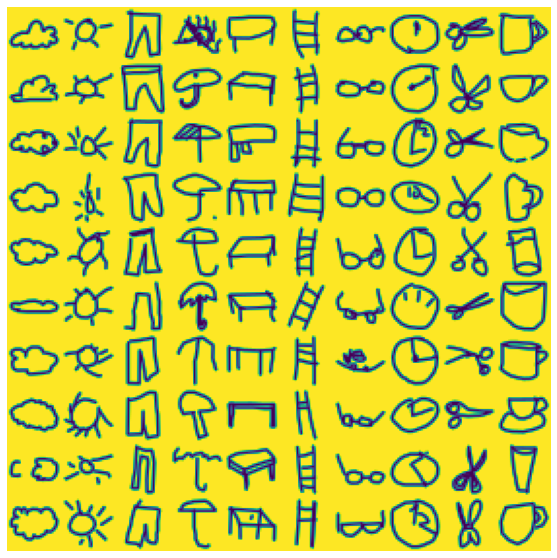

In [7]:
#collapse-hide
def visualize_classes(x_train, y_train):
    for i in range(0, 10):
        img_batch = x_train[y_train == i][0:10]
        img_batch = np.reshape(img_batch, (img_batch.shape[0]*img_batch.shape[1], img_batch.shape[2]))
        if i > 0:
            img = np.concatenate([img, img_batch], axis = 1)
        else:
            img = img_batch
    plt.figure(figsize=(10,10))
    plt.axis('off')
    plt.imshow(img)

visualize_classes(x_train, y_train)

#### Reshaping and Normalizing 

Here the following operations are carried out:
- Reshaping the data
- Normalizing the pixel values by 255
- Changing the datatype to float32

The terms and their meaning: 
- x_train : Train Input Data 
- y_train : Train Labels/Output Data
- x_test : Test Input Data
- y_test : Test Labels/Output Data

In [8]:
#collapse-hide
x1 = x_train.copy() #For future purpose, x_train with 28x28 dimension

# Reshape and normalize
x_train = x_train.reshape(x_train.shape[0], 1, 28, 28).astype('float32')
x_test = x_test.reshape(x_test.shape[0], 1, 28, 28).astype('float32')
x_train /= 255.0
x_test /= 255.0

print("Shape of training dataset ndarray: \n", x_train.shape)

Shape of training dataset ndarray: 
 (400000, 1, 28, 28)


Looks like people enjoyed doodling! 😋 

## Deep Learning
---
In this section I have build and trained a modified version of <b>LeNet</b>. This architecture was developed to classify <b>MNIST Handwritten digits</b> by <b>Yann LeCun</b>. The digit dataset and doodle dataset has similar characterstics. As both of them are grayscale and are also available in same dimensions (for both different number of dimensions are also present). To know more about Yann Lecun's work and MNIST Dataset follow [here](http://yann.lecun.com/exdb/lenet/).

The CNN model performs well over the doodle dataset. It gives good accuracy results over the test dataset. Initially numpy arrays should be transformed into tensors. These tensors are then converted into TensorDataset. Finally these will be then loaded using DataLoaders. The steps of transformation can be followed below,

* ndarray transformed to tensor
* Input(x) tensors and Output(y) tensors are merged together to form TensorDataset
* TensorDataset transformed to DataLoader


For this necessary libraries: torch, torchvision and their modules must be imported. These are implemented in the following code cell.

In [9]:
#collapse-hide
import time
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torchvision import transforms

from torch.utils.data import DataLoader, TensorDataset, Dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu" )
device

#Train data
x_train_tensor = torch.tensor(x_train)
y_train_tensor = torch.tensor(y_train)
train_tensor = TensorDataset(x_train_tensor,y_train_tensor)

#Test data
x_test_tensor = torch.tensor(x_test)
y_test_tensor = torch.tensor(y_test)
test_tensor = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_tensor, batch_size=64, num_workers=2, 
                          shuffle=True) 
test_loader = DataLoader(test_tensor, batch_size=64, num_workers=2, 
                         shuffle=True)

### Convolutinal Neural Network(CNN) Model

The LeNet architecture was first introduced by LeCun et al. in their 1998 paper, [Gradient-Based Learning Applied to Document Recognition](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf).

In [10]:
class LeNet(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 1,out_channels = 6,kernel_size = 5)
        self.conv2 = nn.Conv2d(in_channels = 6,out_channels = 16,kernel_size = 5)
        self.fc_1 = nn.Linear(16 * 4 * 4, 120)
        self.fc_2 = nn.Linear(120, 84)
        self.fc_3 = nn.Linear(84, output_dim)

    def forward(self, x):
        x = self.conv1(x)
        x = F.max_pool2d(x, kernel_size = 2)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.max_pool2d(x, kernel_size = 2)
        x = F.relu(x)
        x = x.view(x.shape[0], -1)
        #h = x
        x = self.fc_1(x)
        x = F.relu(x)
        x = self.fc_2(x)
        x = F.relu(x)
        x = self.fc_3(x)
        return x

In [11]:
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 20, 5, 1)
        self.conv2 = nn.Conv2d(20, 20, 5, 1)
        self.fc1 = nn.Linear(4*4*50, 500)
        self.fc2 = nn.Linear(500, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)
        x = x.view(-1, 4*4*50)
        x = F.relu(self.fc1)
        x = self.fc2(x)
        return F.logsoftmax(x, dim=1)

In [12]:
model = LeNet(10)
criterion = nn.CrossEntropyLoss()
model = model.to(device)
optimizer = optim.Adam(model.parameters()) #Better 
#optimizer = optim.SGD(model.parameters(), lr=0.09) 
model

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc_1): Linear(in_features=256, out_features=120, bias=True)
  (fc_2): Linear(in_features=120, out_features=84, bias=True)
  (fc_3): Linear(in_features=84, out_features=10, bias=True)
)

### Training

Training the model. The CNN architecture has following number of parameters which can be trained. 

In [13]:
#collapse-hide
print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 44,426 trainable parameters


In [14]:
#collapse-hide
EPOCHS = 10

best_valid_loss = float('inf')

for epoch in range(EPOCHS):
    
    start_time = time.time()
    
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, test_loader, criterion, device)
    
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'model.pt')
    
    end_time = time.time()

    epoch_mins, epoch_secs,  = epoch_time(start_time, end_time)
    print('-----------------------------------------------')
    print(f'Epoch: {epoch+1:02}    | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print('-----------------------------------------------')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\tVal. Loss: {valid_loss:.3f}  | Val. Acc: {valid_acc*100:.2f}%')
    

-----------------------------------------------
Epoch: 01    | Epoch Time: 0m 34s
-----------------------------------------------
	Train Loss: 0.293 | Train Acc: 91.40%
	Val. Loss: 0.181  | Val. Acc: 94.69%
-----------------------------------------------
Epoch: 02    | Epoch Time: 0m 35s
-----------------------------------------------
	Train Loss: 0.161 | Train Acc: 95.29%
	Val. Loss: 0.155  | Val. Acc: 95.46%
-----------------------------------------------
Epoch: 03    | Epoch Time: 0m 34s
-----------------------------------------------
	Train Loss: 0.140 | Train Acc: 95.85%
	Val. Loss: 0.142  | Val. Acc: 95.76%
-----------------------------------------------
Epoch: 04    | Epoch Time: 0m 35s
-----------------------------------------------
	Train Loss: 0.128 | Train Acc: 96.20%
	Val. Loss: 0.132  | Val. Acc: 96.10%
-----------------------------------------------
Epoch: 05    | Epoch Time: 0m 35s
-----------------------------------------------
	Train Loss: 0.120 | Train Acc: 96.40%
	Va

### Testing

In [15]:
model.load_state_dict(torch.load('model.pt'))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Test Loss: 0.124 | Test Acc: 96.42%


## Dimensionality Reduction
---
As the name suggests, dimensionality reduction is transformation of data from high dimension space to low dimension space, while trying to retain as much of the information as possible. Dimensionality reduction techniques generally includes PCA or t-SNE. These are mainly used and are powerful techniques.

#### t-SNE

 t-Distributed Stochastic Neighbor Embedding (t-SNE) is an unsupervised, non-linear technique primarily used for data exploration and visualizing high-dimensional data.

In [16]:
#collapse-hide
X = np.reshape(x_train, (x_train.shape[0], 28 * 28))[0:5000]
y = y_train[0:5000]
print("Shape of input data used for t-SNE:", "\nX:", X.shape,"\nY:", y.shape)

Shape of input data used for t-SNE: 
X: (5000, 784) 
Y: (5000,)


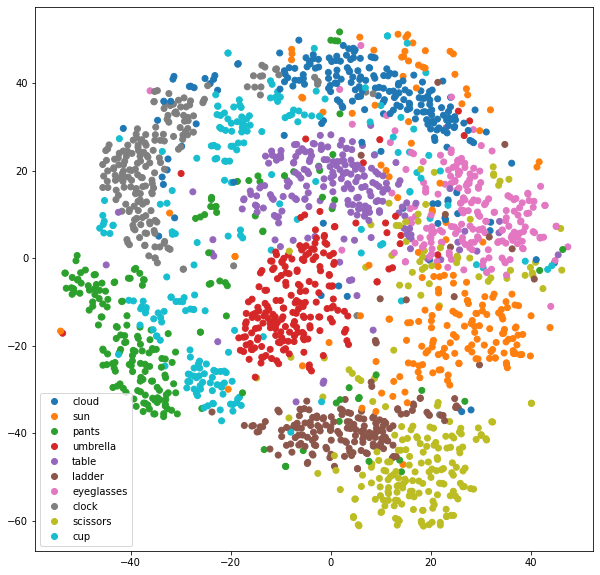

In [17]:
#collapse-hide
out_x = get_tsne(X, n_components=2, n_images=2000)
plot_representations(out_x, y, class_names, n_images=2000)

#### PCA

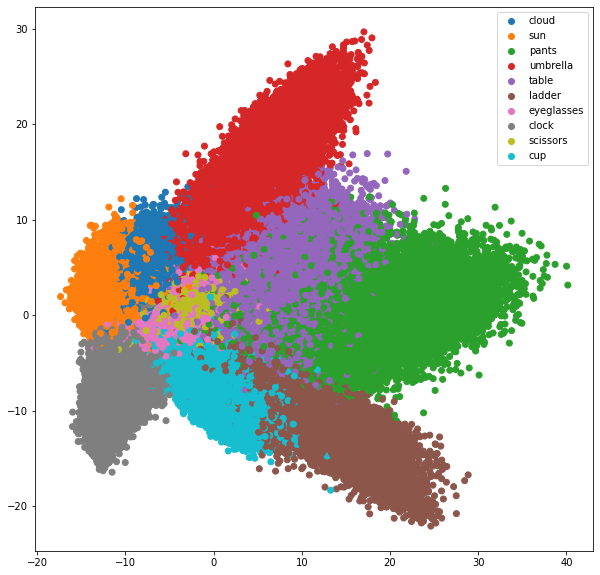

In [18]:
outputs, labels = get_representations(model, train_loader, device)
output_pca_data = get_pca(outputs)
plot_representations(output_pca_data, labels, class_names)

#### t-SNE of Output


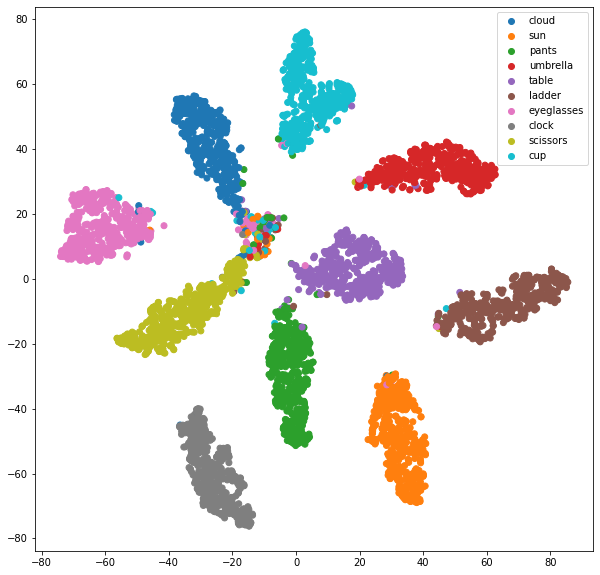

In [19]:
N_IMAGES = 5000

output_tsne_data = get_tsne(outputs, n_images = N_IMAGES)
plot_representations(output_tsne_data, labels, class_names, n_images = N_IMAGES)

---
# END

---